In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, fbeta_score, accuracy_score
)
import matplotlib.pyplot as plt
import glob
import unicodedata

In [3]:
def evaluate(preds, y, target_names, title=""):
    """Print report + F2, show confusion matrix. Returns the predictions."""
    print(f"--- {title} ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=target_names))
    #print(f"F2-score: {fbeta_score(y, preds, beta=2):.4f}\n")
    cm = confusion_matrix(y, preds, labels=target_names)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot()
    plt.title(title)
    return preds

# Data Preparation

In [4]:
files = glob.glob("data/*.csv")

### Loading and Cleaning
First we must concatenate all 8 csv files. They have odd column names with trailing spaces, so names must be normalised. We then clean any rows that contain infinity or NaNs.

In [15]:
df = (
    pd.concat((pd.read_csv(f, encoding_errors="replace") for f in files), ignore_index=True)
    .rename(columns=lambda s: s.strip())
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

### Down-Casting
Down-casting from float64 is inherantly lossy, so below checks if loss > 1e-07 when casting to float32. 

In [16]:
for col in df.select_dtypes("float").columns:
    orig = df[col].astype("float64")
    back = df[col].astype("float32").astype("float64")
    
    # largest relative error introduced
    rel_err = ((back - orig).abs() / orig.abs().replace(0, np.nan)).max()
    print(col, rel_err)

Fwd Packet Length Mean 5.8808532115861154e-08
Fwd Packet Length Std 5.946117860918782e-08
Bwd Packet Length Mean 5.894248777797077e-08
Bwd Packet Length Std 5.9490018992827366e-08
Flow Bytes/s 5.952342611128164e-08
Flow Packets/s 5.9561211665086304e-08
Flow IAT Mean 5.960429305881185e-08
Flow IAT Std 5.9494370761997505e-08
Fwd IAT Mean 5.9603710426339974e-08
Fwd IAT Std 5.952222580744429e-08
Bwd IAT Mean 5.9604513325274406e-08
Bwd IAT Std 5.958431058164412e-08
Fwd Packets/s 5.9561211665086304e-08
Bwd Packets/s 5.9527607936747004e-08
Packet Length Mean 5.9111707366382436e-08
Packet Length Std 5.9580811682697106e-08
Packet Length Variance 5.945458386220663e-08
Average Packet Size 5.8961517633826155e-08
Avg Fwd Segment Size 5.8808532115861154e-08
Avg Bwd Segment Size 5.894248777797077e-08
Active Mean 5.957727658327655e-08
Active Std 5.9495230822478896e-08
Idle Mean 5.960207627408825e-08
Idle Std 5.9463410133870844e-08


In [17]:
# Safely downcasts 64-bit data to 32-bit where there is no information loss
def down_cast(d):
    original_size = d.memory_usage(deep=True).sum()
    for col in d.select_dtypes("integer").columns:
        d[col] = pd.to_numeric(d[col], downcast="integer")
    for col in d.select_dtypes("float").columns:
        d[col] = pd.to_numeric(d[col], downcast="float")
    final_size = d.memory_usage(deep=True).sum()
    print("Size savings: " + str(original_size-final_size) + " bytes")
    return d

df = down_cast(df)

Size savings: 882297312 bytes


We save >0.88 GB for our precious, precious RAM. 

### Data splitting

In [44]:
def normalise(s):
    return (unicodedata.normalize("NFKD", str(s))
            .encode("ascii", "ignore")
            .decode("ascii"))

size = df.shape[0]
df = df.drop_duplicates()
new_size = df.shape[0]
print(size-new_size)
    
X = df.drop("Label", axis=1)
y = df["Label"].apply(normalise)

0


In [45]:
y.value_counts()

Label
BENIGN                       2095051
DoS Hulk                      172846
DDoS                          128014
PortScan                       90694
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack  Brute Force         1470
Web Attack  XSS                  652
Infiltration                      36
Web Attack  Sql Injection         21
Heartbleed                        11
Name: count, dtype: int64

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_test, X_cv, y_test, y_cv       = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42)

In [47]:
X_train.shape[0] + X_test.shape[0] + X_cv.shape[0] == df.shape[0]

True

### Scaling

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
std_scaler = StandardScaler().fit(X_train)
X_train = std_scaler.transform(X_train)
X_cv    = std_scaler.transform(X_cv)
X_test  = std_scaler.transform(X_test)

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
model = LogisticRegression(max_iter=100).fit(X_train, y_train)

/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
preds = model.predict(X_test)

--- log reg on a tuesday ---
accuracy: 0.9718


/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

                           precision    recall  f1-score   support

                   BENIGN       0.99      0.98      0.98    418794
  Web Attack  Brute Force       0.25      0.00      0.01       403
          Web Attack  XSS       0.99      0.97      0.98     25716
Web Attack  Sql Injection       0.92      0.84      0.88      2055
              FTP-Patator       0.98      0.94      0.96     34562
              SSH-Patator       0.84      0.81      0.82      1042
                      Bot       0.89      0.58      0.70      1016
            DoS slowloris       0.91      0.65      0.76      1185
         DoS Slowhttptest       0.00      0.00      0.00         3
                 DoS Hulk       0.00      0.00      0.00         5
            DoS GoldenEye       0.71      0.99      0.83     18321
               Heartbleed       0.37      0.03      0.05       639
             Infiltration       0.00      0.00      0.00       280
                 PortScan       0.00      0.00      0.00     

array(['BENIGN', 'BENIGN', 'BENIGN', ..., 'BENIGN', 'BENIGN', 'BENIGN'],
      shape=(504158,), dtype=object)

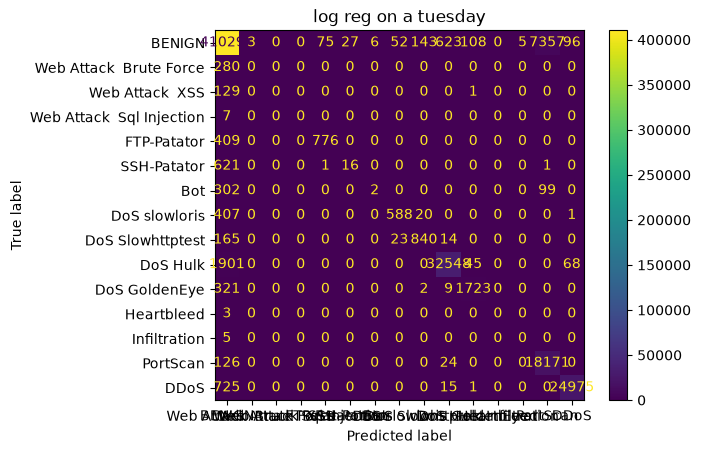

In [53]:
evaluate(preds, y_test, y.unique().tolist(), "log reg on a tuesday")